In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (10,8)
mpl.rcParams['axes.grid'] = False

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
df = pd.read_csv('/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/ML Micro Projects/data/raw/energydata_complete.csv')

In [4]:
df

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,...,17.033333,45.5300,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,...,17.066667,45.5600,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,...,17.000000,45.5000,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,23.200000,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,23.200000,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,23.200000,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,23.200000,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784


| Column Name      | Description                                                                                   |
|------------------|----------------------------------------------------------------------------------------------|
| date             | Date time (year-month-day hour:minute:second)                                                 |
| Appliances       | Energy use in Wh                                                                             |
| lights           | Energy use of light fixtures in the house in Wh                                               |
| T1               | Temperature in kitchen area, in Celsius                                                       |
| RH_1             | Humidity in kitchen area, in %                                                                |
| T2               | Temperature in living room area, in Celsius                                                   |
| RH_2             | Humidity in living room area, in %                                                            |
| T3               | Temperature in laundry room area, in Celsius                                                  |
| RH_3             | Humidity in laundry room area, in %                                                           |
| T4               | Temperature in office room, in Celsius                                                        |
| RH_4             | Humidity in office room, in %                                                                 |
| T5               | Temperature in bathroom, in Celsius                                                           |
| RH_5             | Humidity in bathroom, in %                                                                    |
| T6               | Temperature outside the building (north side), in Celsius                                     |
| RH_6             | Humidity outside the building (north side), in %                                              |
| T7               | Temperature in ironing room, in Celsius                                                       |
| RH_7             | Humidity in ironing room, in %                                                                |
| T8               | Temperature in teenager room 2, in Celsius                                                    |
| RH_8             | Humidity in teenager room 2, in %                                                             |
| T9               | Temperature in parents room, in Celsius                                                       |
| RH_9             | Humidity in parents room, in %                                                                |
| To               | Temperature outside (from Chievres weather station), in Celsius                               |
| Pressure         | Pressure (from Chievres weather station), in mm Hg                                            |
| RH_out           | Humidity outside (from Chievres weather station), in %                                        |
| Wind speed       | Wind speed (from Chievres weather station), in m/s                                            |
| Visibility       | Visibility (from Chievres weather station), in km                                             |
| Tdewpoint        | Dew point temperature (from Chievres weather station), in °C                                  |
| rv1              | Random variable 1, nondimensional                                                             |
| rv2              | Random variable

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,...,17.033333,45.5300,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,...,17.066667,45.5600,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,...,17.000000,45.5000,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,23.200000,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,23.200000,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,23.200000,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,23.200000,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19735 non-null  datetime64[ns]
 1   Appliances   19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   T1           19735 non-null  float64       
 4   RH_1         19735 non-null  float64       
 5   T2           19735 non-null  float64       
 6   RH_2         19735 non-null  float64       
 7   T3           19735 non-null  float64       
 8   RH_3         19735 non-null  float64       
 9   T4           19735 non-null  float64       
 10  RH_4         19735 non-null  float64       
 11  T5           19735 non-null  float64       
 12  RH_5         19735 non-null  float64       
 13  T6           19735 non-null  float64       
 14  RH_6         19735 non-null  float64       
 15  T7           19735 non-null  float64       
 16  RH_7

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

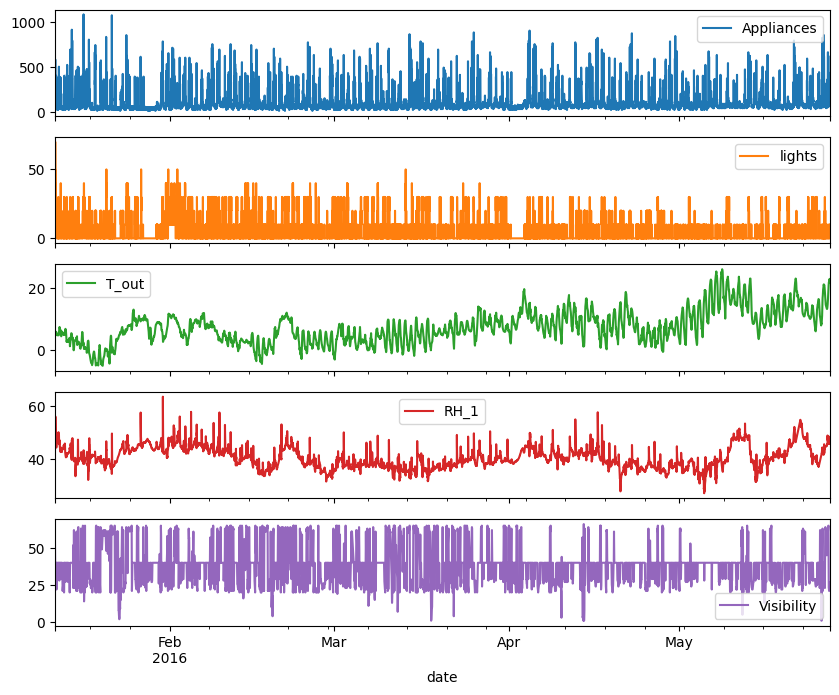

In [9]:
df.set_index('date')[['Appliances', 'lights', 'T_out', 'RH_1', 'Visibility']].plot(subplots=True)

In [10]:
df_input = df[['Appliances', 'T_out', 'RH_1', 'Visibility']]

In [11]:
df_input.describe()

,Appliances,T_out,RH_1,Visibility
count,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,7.411665,40.259739,38.330834
std,102.524891,5.317409,3.979299,11.794719
min,10.000000,-5.000000,27.023333,1.000000
25%,50.000000,3.666667,37.333333,29.000000
50%,60.000000,6.916667,39.656667,40.000000
75%,100.000000,10.408333,43.066667,40.000000
max,1080.000000,26.100000,63.360000,66.000000


In [12]:
df_input.query("Appliances > 500")

,Appliances,T_out,RH_1,Visibility
11,580,5.983333,46.396667,40.000000
314,520,2.900000,41.530000,36.333333
392,550,2.033333,43.433333,40.000000
393,690,2.100000,43.766667,40.000000
394,620,2.166667,43.693333,40.000000
...,...,...,...,...
19586,600,20.833333,44.066667,40.000000
19587,520,20.900000,43.366667,40.000000
19684,580,15.900000,47.226667,61.000000
19685,660,16.100000,47.693333,61.000000


In [13]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_input)

In [14]:
data_scaled

array([[0.04672897, 0.37299035, 0.56618659, 0.95384615],
       [0.04672897, 0.36923901, 0.54132648, 0.89487179],
       [0.03738318, 0.36548767, 0.53050179, 0.83589744],
       ...,
       [0.24299065, 0.88317256, 0.53866618, 0.37435897],
       [0.38317757, 0.87888532, 0.54949087, 0.38717949],
       [0.39252336, 0.87459807, 0.53875791, 0.4       ]])

In [15]:
features = data_scaled
target = data_scaled[:,0]

In [16]:
TimeseriesGenerator(features, target, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.04672897, 0.37299035, 0.56618659, 0.95384615],
         [0.04672897, 0.36923901, 0.54132648, 0.89487179]]]),
 array([0.03738318]))

In [17]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=123, shuffle=False)

In [18]:
x_train.shape

(15788, 4)

In [19]:
x_test.shape

(3947, 4)

In [20]:
win_length = 720
batch_size = 32
num_features = 4
train_generator = TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator = TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [21]:
train_generator[0]

(array([[[0.04672897, 0.37299035, 0.56618659, 0.95384615],
         [0.04672897, 0.36923901, 0.54132648, 0.89487179],
         [0.03738318, 0.36548767, 0.53050179, 0.83589744],
         ...,
         [0.06542056, 0.25241158, 0.31584258, 0.79230769],
         [0.05607477, 0.23901393, 0.31309054, 0.72820513],
         [0.06542056, 0.22561629, 0.31107238, 0.66410256]],
 
        [[0.04672897, 0.36923901, 0.54132648, 0.89487179],
         [0.03738318, 0.36548767, 0.53050179, 0.83589744],
         [0.03738318, 0.36173633, 0.52408036, 0.77692308],
         ...,
         [0.05607477, 0.23901393, 0.31309054, 0.72820513],
         [0.06542056, 0.22561629, 0.31107238, 0.66410256],
         [0.06542056, 0.21221865, 0.30923768, 0.6       ]],
 
        [[0.03738318, 0.36548767, 0.53050179, 0.83589744],
         [0.03738318, 0.36173633, 0.52408036, 0.77692308],
         [0.04672897, 0.35798499, 0.53141914, 0.71794872],
         ...,
         [0.06542056, 0.22561629, 0.31107238, 0.66410256],
        

In [22]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape= (win_length, num_features), return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.LSTM(128, return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.LSTM(64, return_sequences=False))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(1))

2025-08-10 15:43:38.579402: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-08-10 15:43:38.579551: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-08-10 15:43:38.580657: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-08-10 15:43:38.581191: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-10 15:43:38.581591: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 720, 128)       │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 720, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 720, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 720, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 720, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,153 (973.25 KB)

 Trainable params: 249,153 (973.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', 
                                                    patience=2, 
                                                    mode='min')

model.compile(loss=tf.losses.MeanSquaredError(),
              optimizer=tf.optimizers.Adam(),
              metrics=[tf.metrics.MeanAbsoluteError])


In [25]:
with tf.device('/device:GPU:0'):
    history = model.fit(train_generator, epochs=50,
                              validation_data=test_generator,
                              shuffle=False,
                              callbacks=[early_stopping])

Epoch 1/50


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-08-10 15:44:14.554372: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


471/471 ━━━━━━━━━━━━━━━━━━━━ 76s 151ms/step - loss: 0.0116 - mean_absolute_error: 0.0618 - val_loss: 0.0058 - val_mean_absolute_error: 0.0495
Epoch 2/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - loss: 0.0087 - mean_absolute_error: 0.0507 - val_loss: 0.0047 - val_mean_absolute_error: 0.0415
Epoch 3/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - loss: 0.0062 - mean_absolute_error: 0.0408 - val_loss: 0.0034 - val_mean_absolute_error: 0.0314
Epoch 4/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - loss: 0.0049 - mean_absolute_error: 0.0349 - val_loss: 0.0032 - val_mean_absolute_error: 0.0270
Epoch 5/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - loss: 0.0046 - mean_absolute_error: 0.0337 - val_loss: 0.0032 - val_mean_absolute_error: 0.0285
Epoch 6/50
471/471 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - loss: 0.0047 - mean_absolute_error: 0.0333 - val_loss: 0.0032 - val_mean_absolute_error: 0.0281


In [28]:
model.evaluate(test_generator, verbose=0)

[0.003194196382537484, 0.028105732053518295]

In [29]:
predictions = model.predict(test_generator)

101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step


In [30]:
predictions

array([[0.07234566],
       [0.08872887],
       [0.11016231],
       ...,
       [0.09587498],
       [0.23708315],
       [0.27178073]], dtype=float32)

In [31]:
predictions.shape

(3227, 1)

In [33]:
y_test

array([0.3364486 , 0.54205607, 0.28971963, ..., 0.24299065, 0.38317757,
       0.39252336])

In [34]:
x_test

array([[0.3364486 , 0.34297964, 0.30923768, 0.6       ],
       [0.54205607, 0.34726688, 0.3055683 , 0.6       ],
       [0.28971963, 0.35155413, 0.30455921, 0.6       ],
       ...,
       [0.24299065, 0.88317256, 0.53866618, 0.37435897],
       [0.38317757, 0.87888532, 0.54949087, 0.38717949],
       [0.39252336, 0.87459807, 0.53875791, 0.4       ]])

In [35]:
x_test[:,1:][win_length:]

array([[0.45337621, 0.20851298, 0.6       ],
       [0.47106109, 0.18282726, 0.6       ],
       [0.48874598, 0.18466196, 0.6       ],
       ...,
       [0.88317256, 0.53866618, 0.37435897],
       [0.87888532, 0.54949087, 0.38717949],
       [0.87459807, 0.53875791, 0.4       ]])

In [37]:
df_pred = pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)

In [38]:
df_pred

,0,0,1,2
0,0.072346,0.453376,0.208513,0.600000
1,0.088729,0.471061,0.182827,0.600000
2,0.110162,0.488746,0.184662,0.600000
3,0.311058,0.506431,0.193996,0.600000
4,0.151579,0.524116,0.181818,0.600000
...,...,...,...,...
3222,0.094260,0.891747,0.537657,0.348718
3223,0.105726,0.887460,0.536006,0.361538
3224,0.095875,0.883173,0.538666,0.374359
3225,0.237083,0.878885,0.549491,0.387179


In [39]:
rev_trans = scaler.inverse_transform(df_pred)

In [40]:
rev_trans

array([[ 87.40985528,   9.1       ,  34.6       ,  40.        ],
       [104.93989617,   9.65      ,  33.66666667,  40.        ],
       [127.87367202,  10.2       ,  33.73333333,  40.        ],
       ...,
       [112.5862287 ,  22.46666667,  46.59666667,  25.33333333],
       [263.67897257,  22.33333333,  46.99      ,  26.16666667],
       [300.80538034,  22.2       ,  46.6       ,  27.        ]])

In [ ]:
predictions.shape[0]-1

-3227

In [47]:
df_final = df_input[predictions.shape[0]*-1:]

In [48]:
df_final

,Appliances,T_out,RH_1,Visibility
16508,90,9.100000,34.600000,40.000000
16509,120,9.650000,33.666667,40.000000
16510,390,10.200000,33.733333,40.000000
16511,240,10.750000,34.072500,40.000000
16512,120,11.300000,33.630000,40.000000
...,...,...,...,...
19730,100,22.733333,46.560000,23.666667
19731,90,22.600000,46.500000,24.500000
19732,270,22.466667,46.596667,25.333333
19733,420,22.333333,46.990000,26.166667


In [49]:
df_final.count()

Appliances    3227
T_out         3227
RH_1          3227
Visibility    3227
dtype: int64

In [50]:
df_final['App_pred'] = rev_trans[:,0]

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_34059/3952543898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['App_pred'] = rev_trans[:,0]


In [51]:
df_final

,Appliances,T_out,RH_1,Visibility,App_pred
16508,90,9.100000,34.600000,40.000000,87.409855
16509,120,9.650000,33.666667,40.000000,104.939896
16510,390,10.200000,33.733333,40.000000,127.873672
16511,240,10.750000,34.072500,40.000000,342.832331
16512,120,11.300000,33.630000,40.000000,172.189522
...,...,...,...,...,...
19730,100,22.733333,46.560000,23.666667,110.858495
19731,90,22.600000,46.500000,24.500000,123.126728
19732,270,22.466667,46.596667,25.333333,112.586229
19733,420,22.333333,46.990000,26.166667,263.678973


<Axes: >

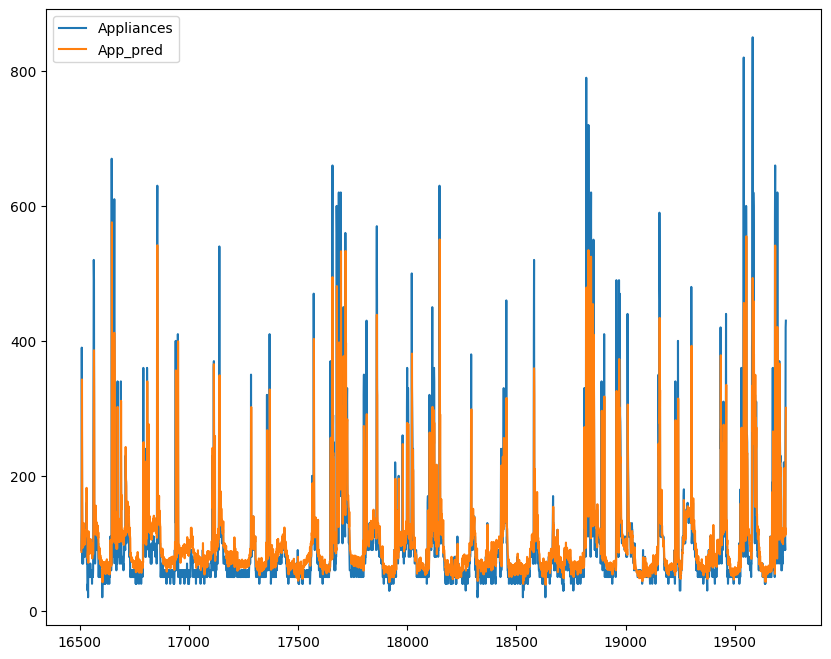

In [52]:
df_final[['Appliances', 'App_pred']].plot()